In [1]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from src.models.utils import *
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def check(X,y):
    # تعریف مدل SVM با کرنل خطی (Linear Kernel)
    model = SVC(kernel='linear')
    # آموزش مدل
    model.fit(X, y)
    # پیش‌بینی روی داده تست
    y_pred = model.predict(X)
    #print("Accuracy:", accuracy_score(y, y_pred))
    return y_pred
    # دقت مدل
    
def select_month(df,m1,m2,y1,y2):
    df["datetime"] = pd.to_datetime(df["datetime"])
    year_s  = df["datetime"].dt.year
    month_s = df["datetime"].dt.month
    mask1 = (year_s == y1) & (month_s == m1)
    mask2 = (year_s == y2) & (month_s == m2)
    df_month = df[mask1|mask2]
    df_month["label_month"] = 1
    mm1 = mask1[mask1]
    mm2 = mask2[mask2]
    df_month.loc[mm1.index,"label_month"] = 1
    df_month.loc[mm2.index,"label_month"] = 2
    return df_month,len(mm1),len(mm2)

def my_func(x,th):
    if x == None:
        return None
    if x > th:
        return 1
    return 0


In [ ]:
def get_el(a,i,f,weigth):
    
    if i < 0 or i >= len(a):
        return 0,0
    if a[i] == None:
        if f : return 0,0
        else : return 0,0
        
    if type(weigth) != np.ndarray: w = 1
    else: w = weigth[i]
    
    return a[i]*w,w
def normal_filter(array,index,k,filter=True,weigth=None):
    k = min(index+1,k)
    k = min(len(array)-index,k)
    m = 0
    n = 0
    for i in range(index-k,index+k+1):
        mm,nn = get_el(array,i,i==index,weigth)
        m += mm
        n += nn
        
    if n == 0:
        return None
    
    f = m/n
    if filter:
        f = 1 if f > 0.5 else 0
    return f
def f(result,k,filter=True,weigth=None):
    return np.array([normal_filter(result,i,k=k,filter=filter,weigth=weigth) for i in range(len(result))])
def f_n(result,k,n,filter=True,weigth=None):
    for i in range(n):
        result = f(result,k,filter=filter,weigth=weigth)
    return result

In [4]:
def find_intervals(arr, k):
    start = None
    count = 0
    intervals = []
    #print(len(arr))
    for i, num in enumerate(arr):
        if num == 1:
            if start is None:
                start = i  # شروع بازه جدید
            count += 1
        elif num == 0:
            if count > k:
                intervals.append((start, i))
            start = None
            count = 0
    
    # بررسی بازه پایانی
    if count >= k or count == len(arr):
        intervals.append((start, len(arr)))
    
    return intervals


def find_time_intervals(intervals,dates):
        
    end = len(dates)
    last_time = max(dates)
    k = []
    y1 = np.timedelta64(1,'Y').astype('timedelta64[ns]')#pd.DateOffset(years=1)#np.datesdelta64(1,'M').astype('datesdelta64[ns]')
    m1 = np.timedelta64(1,'M').astype('timedelta64[ns]')
    for i1,i2 in intervals:
        if i2 != end:
            #print("RR",i2,end,dates[i2])
            k.append(dates[i2-1]+m1)
        else :
            #print("GG",dates[i1]+y1,last_time,dates[i2])
            k.append(min(dates[i1],last_time)+y1)
    return k

In [5]:
from src.models.data_selection.data_selector import Data_selector
def label_points(df, ds, power_plants, dates_by_name_code, label):
    all_indices = []
    for _, row in power_plants.iterrows():
        name, code = row['name'], row['code']
        df_name_code = ds.filter_name_code(name, code)
        dates = dates_by_name_code[(name, code)]

        interval_ds = Data_selector(df_name_code)
        for date1, date2 in dates:
            flag_array = interval_ds.filter_time(date1, date2, get_mask=True)
            indices = flag_array.index[flag_array]
            all_indices.extend(indices)
    df.loc[all_indices, "is_good_peak"] = label

In [6]:
def label_points_my(df, ds, power_plants, dates_by_name_code):
    df['color'] = 0
    for _, row in power_plants.iterrows():
        name, code = row['name'], row['code']
        df_name_code = ds.filter_name_code(name, code)
        dates = dates_by_name_code[(name, code)]

        interval_ds = Data_selector(df_name_code)
        k = 0
        print(name,code,dates)
        print(type(df_name_code.iloc[0]))
        for date1, date2 in dates:
            print(type(date1),type(date2))
            all_indices = [] 
            flag_array = interval_ds.filter_time(date1, date2, get_mask=True,close_open=True)
            indices = flag_array.index[flag_array]
            all_indices.extend(indices)
            df.loc[all_indices, "color"] = k
            k += 1

In [7]:
import plotly.express as px
def show(df_m1,save=False,parm=None,ass=""):

    fig = px.scatter(df_m1, x="datetime", y='generation', color='color',
                    title='Generation over Time by Batch Interval',
                    labels={'generation': 'Generation', 'datetime': 'Time'},
                    hover_data=['datetime', 'generation', 'temperature','interval_id'])
    
    if save : fig.write_html(f"{project_root}/src/visualization/unit_figs/filter4{ass}/{parm['name']}-{parm['code']}.html")
    else : fig.show()
    
    fig = px.scatter(df_m1, x="temperature", y='generation', color='color',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation', 'datetime': 'Time'},
                hover_data=['datetime', 'generation', 'temperature','interval_id'])
    if save: fig.write_html(f"{project_root}/src/visualization/unit_figs/filter4{ass}/{parm['name']}-{parm['code']}_s.html")
    else: fig.show()
    

In [ ]:
def get_df_of_year_and_month(df):
    datetime = pd.to_datetime(df['datetime'])
    start = datetime.min().replace(day=1)
    end = datetime.max().replace(day=1)
    
    full_range = pd.date_range(start=start, end=end, freq='MS')
    df_full_range = pd.DataFrame({'year_month': full_range})['year_month']
    df_year_month =  pd.DataFrame({'year': df_full_range.dt.year, 'month': df_full_range.dt.month})
    
    return df_year_month,start,end

def get_date_interval(result,dates,weigth,min_date,max_date,th,k_filter=6,n_filter=1,l_min=3,get_last=True):
    result1 = f_n(result,k=k_filter,n=n_filter,filter=False,weigth=weigth)
    result2 = np.array([my_func(x,th) for x in result1])
    intervals = find_intervals(result2, k=l_min)
    dates_interval = find_time_intervals(intervals,dates)
    
    time_e = [min_date] + dates_interval + [max_date+pd.DateOffset(months=1)]
    time_intervals = [(time_e[i],time_e[i+1]) for i in range(len(time_e)-1)]
    
    if get_last and time_intervals != [] : time_intervals = [time_intervals[-1]]
    return time_intervals

def compare_months(df_name_code,df_year_month):
    weigth = []
    accuracies = []
    dates = []
    
    df_year_month = df_year_month.iloc[0:-12]
    for _,row in df_year_month.drop_duplicates().iterrows():
        month = row['month']
        year = row['year']
        year1 = year
        year2 = year + 1     
        datetime = pd.to_datetime({'year': [year], 'month': [month], 'day': [1]})
        
        df_month,n1,n2 = select_month(df_name_code,month,month,year1,year2)
        weigth.append(n1+n2)
    
        if n1 != 0 and n2 != 0:    
            X = df_month[["generation"]+["temperature"]]
            y = df_month["label_month"]
            y_pred = check(X,y)
            d = classification_report(y, y_pred,output_dict=True,zero_division=0)
            accuracies.append(d['accuracy'])
            dates.append(datetime[0])
        else:
            accuracies.append(None)
            dates.append(datetime[0])
            
    result = np.array(accuracies)
    dates = np.array(dates)
    weigth = np.array(weigth)/sum(weigth)
    return 

In [ ]:
pd.set_option('future.no_silent_downcasting', True)
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

th = 0.9
k_filter = 6
n_filter = 4
l_min = 3

feature = ['name','code',"datetime", "generation","temperature", "is_good_peak"]
df_modified = df[feature].copy(deep=True)
df_modified = df_modified[df_modified['is_good_peak']>=3]
df_modified['datetime'] = pd.to_datetime(df_modified['datetime'])

power_plants = df_modified[['name', 'code']].drop_duplicates()
ds = Data_selector(df_modified)

dates_by_name_code={}
for _, row in power_plants.iterrows():
    name, code = row['name'], row['code']
    
    if code.startswith("S"):
        dates_by_name_code[(name,code)] = []
        continue
    
    df_name_code = ds.filter_name_code(name,code)
    if len(df_name_code) == 0:
        dates_by_name_code[(name,code)] = []
        continue
    
    df_year_month,min_date,max_date = get_df_of_year_and_month(df_name_code)
    weigth,accuracies,dates = compare_months(df_name_code,df_year_month)
    dates_by_name_code[(name,code)] = get_date_interval(accuracies,dates,weigth,min_date,max_date,th,k_filter,n_filter,l_min)
    
df_m1 = df.copy()
label_points(df_m1, ds, power_plants, dates_by_name_code, label=4)


In [11]:
#label_points_my(df_m1, ds, power_plants, dates_by_name_code)

In [12]:
df_m1[df_m1["is_good_peak"] == 3]

,id,name,code,date,hour,temperature,humidity,dew,apparent_temperature,precipitation,...,temperature_with_1_delay,temperature_with_5_delay,humidity_with_1_delay,humidity_with_5_delay,dew_with_1_delay,dew_with_5_delay,surface_pressure_with_1_delay,surface_pressure_with_5_delay,generation_with_24_delay,interval_id
169129,917,حافظ,G15,2021-05-25,9,32.296000,10.0,-3.200995,32.308945,0.0,...,31.396000,25.196000,10.0,20.0,-3.884186,0.637603,847.40796,847.10046,121.221970,0.0
169130,917,حافظ,G15,2021-05-25,10,33.196003,11.0,-1.224276,29.123486,0.0,...,32.296000,27.095999,10.0,18.0,-3.200995,0.734129,847.14630,847.41880,119.036380,0.0
169131,917,حافظ,G15,2021-05-25,11,33.396000,10.0,-2.366775,26.027643,0.0,...,33.196003,29.396000,11.0,14.0,-1.224276,-0.884337,846.96630,847.82874,117.364920,0.0
169132,917,حافظ,G15,2021-05-25,12,32.696003,12.0,-0.417661,25.789995,0.0,...,33.396000,30.595999,10.0,11.0,-2.366775,-3.219042,846.29640,847.62850,115.411980,0.0
169133,917,حافظ,G15,2021-05-25,13,32.096000,12.0,-0.882327,25.009330,0.0,...,32.696003,31.396000,12.0,10.0,-0.417661,-3.884186,845.97700,847.40796,114.657380,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
774395,104,پرند,G12,2022-02-24,21,13.278000,39.0,-0.393514,10.175630,0.0,...,13.528000,15.778000,39.0,33.0,-0.169484,-0.470848,897.39825,897.65620,124.942936,121.0
774536,104,پرند,G12,2022-03-02,18,14.328000,41.0,1.241963,10.277030,0.0,...,14.628000,16.328000,41.0,34.0,1.512214,0.424594,895.27155,894.78094,110.704306,122.0
774537,104,پرند,G12,2022-03-02,19,13.728000,43.0,1.363718,10.010991,0.0,...,14.328000,16.227999,41.0,34.0,1.241963,0.336477,895.68396,894.65424,122.163102,122.0
774538,104,پرند,G12,2022-03-02,20,13.428000,43.0,1.091901,9.690181,0.0,...,13.728000,15.328000,43.0,35.0,1.363718,-0.057862,895.45010,894.66090,120.403930,122.0


In [50]:
name = "پرند"
code = "G12"
show(Data_selector(Data_selector(df_m1).filter_name_code(name,code)).select_good_peaks(goodness=3))

# A

In [ ]:
'''
جنوب اصفهان - چهلستون G11 @ 0.9 3 4 | ندارد
حافظ G11 @ 0.9 3 4 @ وزن دار
حافظ G15 @ 0.9 3 4
سبلان G12 @ 0.9 3 4 @ ایده فیلتر وزن دار | ندارد
سیکل ترکیبی ارومیه G11  @ 0.9 3 4
سیکل ترکیبی شیروان G11  @ 0.9 3 4
شهدای پیروز - بهبهان G11 @ 0.91 3 4  @ ایده فیلتر اولیه
عسلویه G11 @ 0.9 3 4   | no
عسلویه G12 @ 0.9 3 4
پرند G11 @ 0.9 3 4
پرند G12 @ 0.9 3 4
'''


'\nجنوب اصفهان - چهلستون G11 @ 0.9 3 4 | ندارد\nحافظ G11 @ 0.9 3 4 @ وزن دار\nحافظ G15 @ 0.9 3 4\nسبلان G12 @ 0.9 3 4 @ ایده فیلتر وزن دار | ندارد\nسیکل ترکیبی ارومیه G11  @ 0.9 3 4\nسیکل ترکیبی شیروان G11  @ 0.9 3 4\nشهدای پیروز - بهبهان G11 @ 0.91 3 4  @ ایده فیلتر اولیه\nعسلویه G11 @ 0.9 3 4   | no\nعسلویه G12 @ 0.9 3 4\nپرند G11 @ 0.9 3 4\nپرند G12 @ 0.9 3 4\n'

In [ ]:
pd.set_option('future.no_silent_downcasting', True)
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

In [ ]:
name = "جنوب اصفهان - چهلستون"  # "شهدای پیروز - بهبهان" #"جنوب اصفهان - چهلستون"
code = "G11" # "G16"
th = 0.9
k_filter = 3
n_filter = 4


weigth = []
df_m = df[(df["name"] == name)&(df["code"] == code)&(df['is_good_peak'] >= 3)]
array = []
time = []
#print(df_m)
df_m['datetime'] = pd.to_datetime(df_m['datetime'])
start = df_m['datetime'].min().replace(day=1)
end = df_m['datetime'].max().replace(day=1)
full_range = pd.date_range(start=start, end=end, freq='MS')
df_full_range = pd.DataFrame({'year_month': full_range})['year_month']
df_new = pd.DataFrame({'year': df_full_range.dt.year, 'month': df_full_range.dt.month})

for _,row in df_new.drop_duplicates().iterrows():
    month = row['month']
    year = row['year']
    year1 = year
    year2 = year + 1
    
    datetime = pd.to_datetime({'year': [year], 'month': [month], 'day': [1]})
    df_month,n1,n2 = select_month(df_m,month,month,year1,year2)
    print(n1,n2,"tg",datetime)
    weigth.append(n1+n2)
    if n1!=0 and n2!=0 :#n1 >= 10 and n2 >= 10 and abs(n1-n2)/(n1+n2)*2<0.8:    
        X = df_month[["generation"]+["temperature"]]
        y = df_month["label_month"]
        y_pred = check(X,y)
        d = classification_report(y, y_pred,output_dict=True,zero_division=0)
        array.append(d['accuracy'])
        time.append(datetime[0])
    else:
        array.append(None)
        time.append(datetime[0])
 
weigth = np.array(weigth)[:-12]
array = np.array(array)[:-12]
time = np.array(time)[:-12]
weigth = weigth.astype(float)/float(sum(weigth))

In [ ]:
len(time),len(array),weigth

(33,
 33,
 array([0.02749467, 0.09931263, 0.0948092 , 0.09907561, 0.03934582,
        0.00094809, 0.00379237, 0.00758474, 0.00568855, 0.00379237,
        0.00189618, 0.        , 0.        , 0.04977483, 0.0772695 ,
        0.09433515, 0.04930078, 0.00189618, 0.00284428, 0.00568855,
        0.00758474, 0.00474046, 0.        , 0.        , 0.00260725,
        0.0381607 , 0.12277791, 0.09243897, 0.04977483, 0.00379237,
        0.00189618, 0.00474046, 0.00663664]))

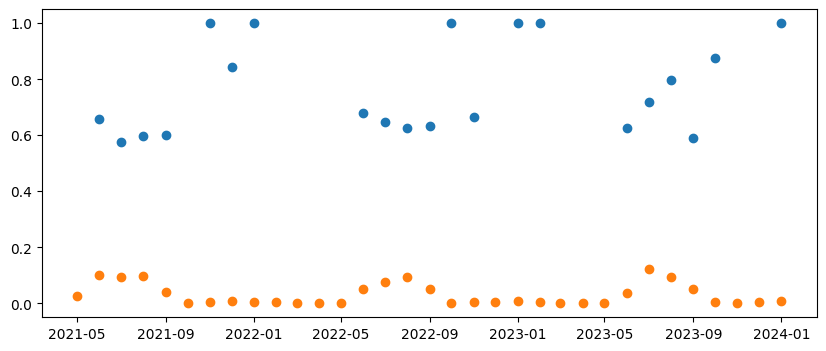

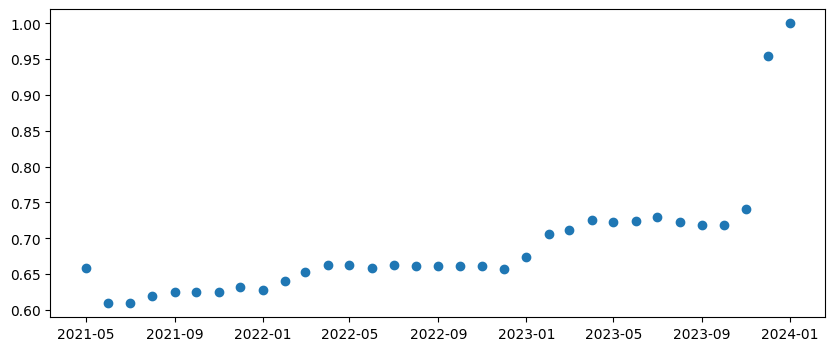

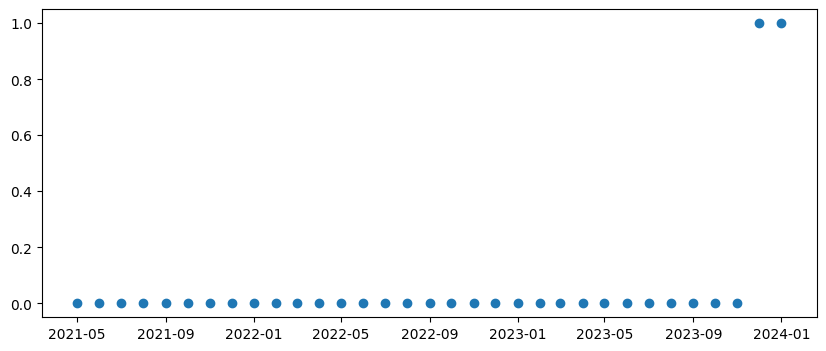

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(time,array)
plt.scatter(time,weigth)
plt.show()
weigth
aarray = f_n(array,k=6,n=1,filter=False,weigth=weigth)

plt.figure(figsize=(10,4))
plt.scatter(time,aarray)
plt.show()

result = np.array([my_func(x,th) for x in aarray])

plt.figure(figsize=(10,4))
plt.scatter(time,result)
plt.show()

#result = f_n(result,k=1,n=n_filter)

intervals = find_intervals(result, k=3)
dates_interval = find_time_intervals(intervals,time)

In [ ]:
dates_interval

[]

In [ ]:
ds = Data_selector(df_m)
power_plants = df_m[['name', 'code']].drop_duplicates()
#dates_interval=[pd.to_datetime('2022-01-01 02:00:00')]
time_e = [min(df_m["datetime"])] + dates_interval + [max(df_m["datetime"]) + pd.DateOffset(days=1)]
time_intervals = [(time_e[i],time_e[i+1]) for i in range(len(time_e)-1)]
dates_by_name_code = {(name,code):time_intervals}
df_m1 = df_m.copy()
label_points_my(df_m1, ds, power_plants, dates_by_name_code)

import plotly.express as px

fig = px.scatter(df_m1, x="datetime", y='generation', color='color',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation', 'datetime': 'Time'},
                hover_data=['datetime', 'generation', 'temperature','interval_id'])
fig.show()

fig = px.scatter(df_m1, x="temperature", y='generation', color='color',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation', 'datetime': 'Time'},
                hover_data=['datetime', 'generation', 'temperature','interval_id'])
fig.show()